β = 1.0437  |  intercept = 0.5396  |  train: 1258 steps, test: 3774 steps


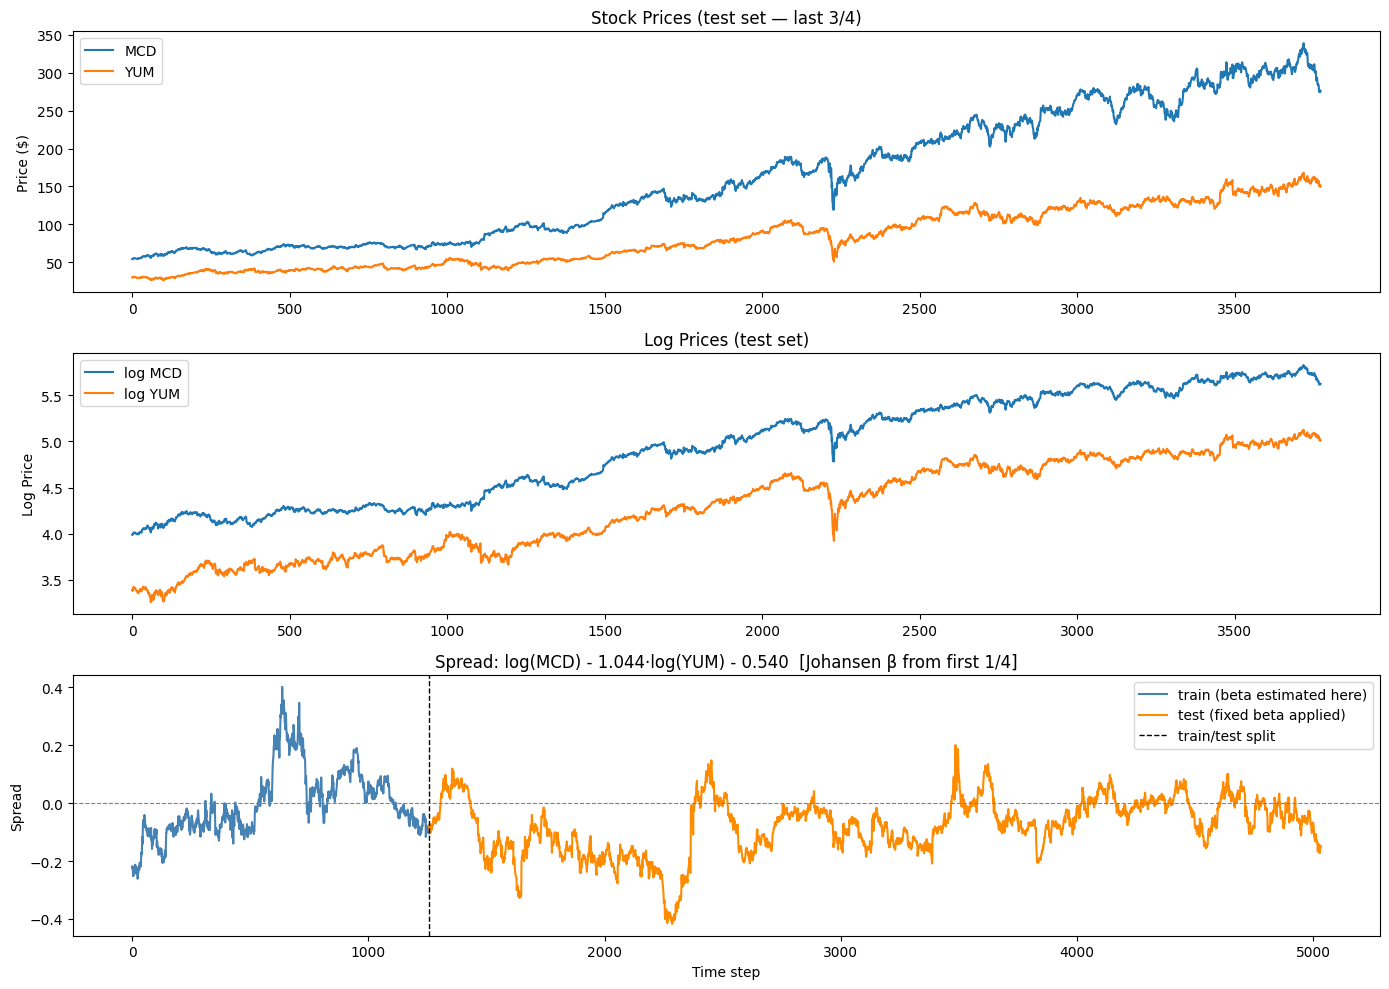

In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from data_loader import PairData

data = PairData("../../data/real_pair_MCD_YUM.csv")
s0, s1 = data.s[0], data.s[1]
labels = data.labels
n = len(s0)
train_end = n // 4

# Estimate beta on first 1/4 only
log_s0, log_s1 = np.log(s0), np.log(s1)
jres = coint_johansen(np.column_stack([log_s0[:train_end], log_s1[:train_end]]), det_order=0, k_ar_diff=1)
cv   = jres.evec[:, 0]
beta = -cv[1] / cv[0]

# Intercept from training period so spread is centred around 0
intercept = (log_s0[:train_end] - beta * log_s1[:train_end]).mean()

spread_train = log_s0[:train_end] - beta * log_s1[:train_end] - intercept
spread_test  = log_s0[train_end:] - beta * log_s1[train_end:] - intercept

print(f"β = {beta:.4f}  |  intercept = {intercept:.4f}  |  train: {train_end} steps, test: {n - train_end} steps")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# --- Prices (test set only) ---
axes[0].plot(s0[train_end:], label=labels[0])
axes[0].plot(s1[train_end:], label=labels[1])
axes[0].set_title("Stock Prices (test set — last 3/4)")
axes[0].set_ylabel("Price ($)")
axes[0].legend()

# --- Log prices (test set only) ---
axes[1].plot(log_s0[train_end:], label=f"log {labels[0]}")
axes[1].plot(log_s1[train_end:], label=f"log {labels[1]}")
axes[1].set_title("Log Prices (test set)")
axes[1].set_ylabel("Log Price")
axes[1].legend()

# --- Spread: train + test, separated by vertical line ---
ax = axes[2]
ax.plot(np.arange(train_end),         spread_train, color="steelblue",  label="train (beta estimated here)")
ax.plot(np.arange(train_end, n),      spread_test,  color="darkorange", label="test (fixed beta applied)")
ax.axvline(train_end, color="black", linewidth=1, linestyle="--", label="train/test split")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title(f"Spread: log(MCD) - {beta:.3f}·log(YUM) - {intercept:.3f}  [Johansen β from first 1/4]")
ax.set_ylabel("Spread")
ax.set_xlabel("Time step")
ax.legend()

plt.tight_layout()
plt.show()


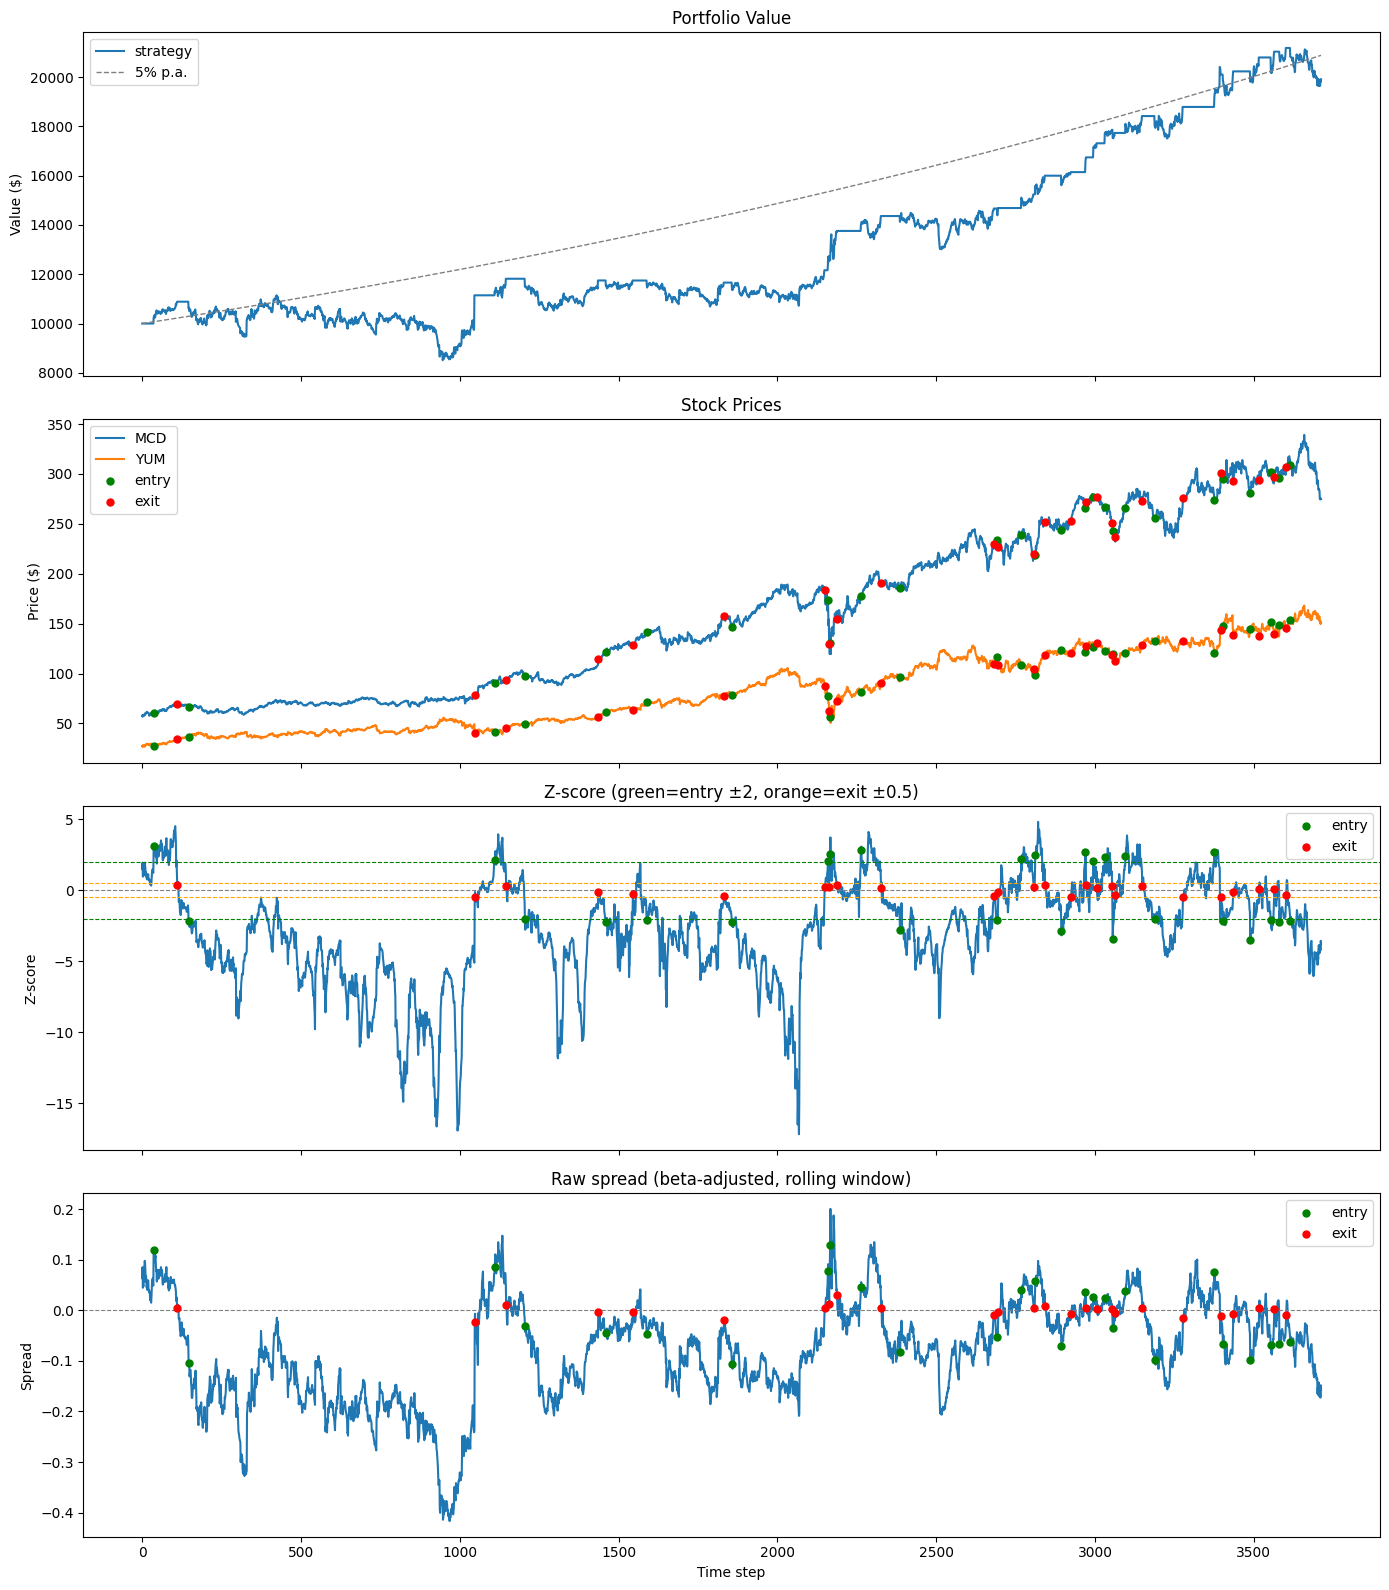

In [2]:
from env import Market
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy

test_data = data.slice(train_end)
env = Market(test_data, fixed_beta=beta, spread_intercept=intercept)
results = run_strategy(env, ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
plot_strategy(results)
